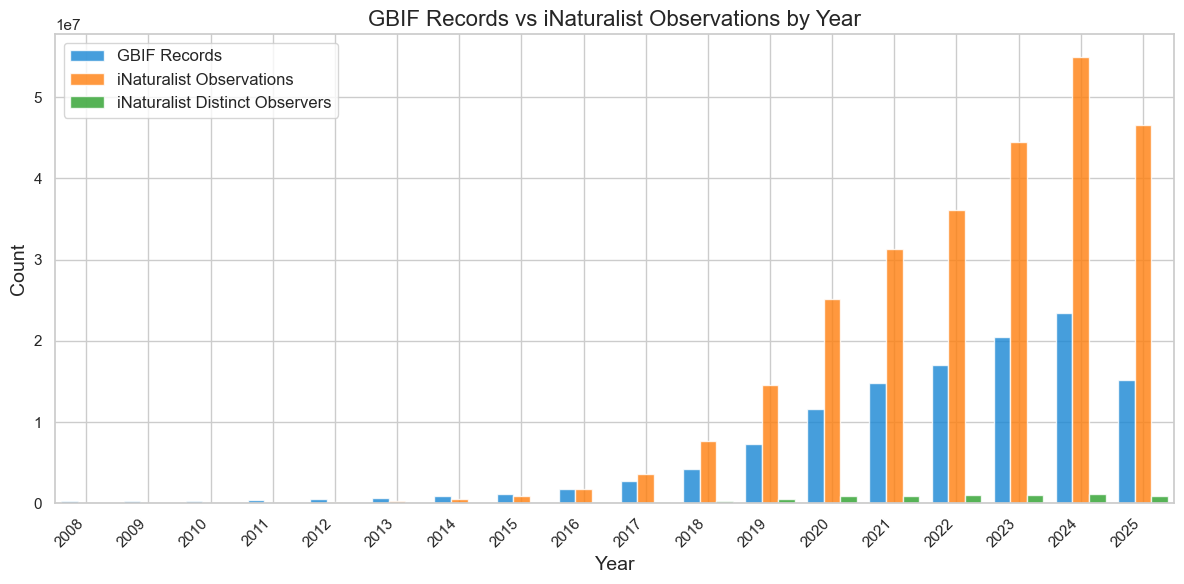

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

path = '../data/inaturalist/metrics/inat_gbif_growth_20250825.parquet'

df = pd.read_parquet(path)
df = df.set_index('year')
df.index = pd.to_datetime(df.index, format='%Y')

df_recent = df.loc[df.index.year >= 2008].copy()

fig, ax = plt.subplots(figsize=(12, 6))

df_recent[['gbif_records', 'inat_observations', 'inat_distinct_observers']].plot(
    kind='bar', ax=ax, width=0.8,
    color=["#1886d4", '#ff7f0e', '#2ca02c'], alpha=0.8
)

ax.set_title('GBIF Records vs iNaturalist Observations by Year', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(['GBIF Records', 'iNaturalist Observations', 'iNaturalist Distinct Observers'], fontsize=12)

# ❌ REMOVA isso (era o que escondia tudo)
# ax.set_xlim([2008-0.5, 2025+0.5])

# ✅ Se quiser limitar corretamente, use índices posicionais:
ax.set_xlim(-0.5, len(df_recent) - 0.5)

# Deixa os rótulos bonitos com o ano
ax.set_xticklabels(df_recent.index.year, rotation=45, ha='right')

plt.tight_layout()
plt.show()


    year  inat_obs_mammals_br  inat_users_mammals_br  \
13  2021               5536.0                 1671.0   
14  2022               8840.0                 2417.0   
15  2023              11471.0                 2999.0   
16  2024              15715.0                 3514.0   
17  2025              12114.0                 2799.0   

    inat_obs_mammals_sudeste  inat_users_mammals_sudeste  
13                      3081                        1072  
14                      4154                        1262  
15                      5313                        1444  
16                      7300                        1558  
17                      6935                        1599  


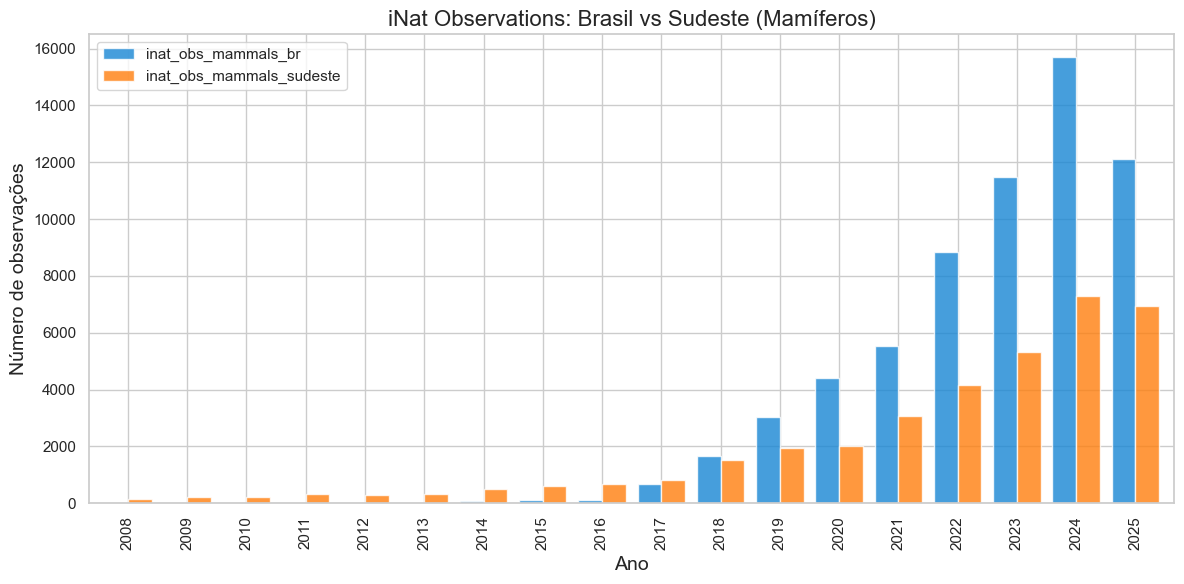

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

path_br = '../data/inaturalist/metrics/inat_gbif_mammals_br_20250825.parquet'
path_se = '../data/inaturalist/metrics/inat_gbif_mammals_sudeste_20250930.parquet'

# ---------------------------
# 1) Carregar e preparar BR (sem set_index)
# ---------------------------
df_br = pd.read_parquet(path_br)
df_br = df_br[df_br["year"] >= 2008].copy()
df_br["year"] = df_br["year"].astype(int)
df_br = df_br[["year", "inat_obs_mammals_br", "inat_users_mammals_br"]]

# ---------------------------
# 2) Carregar e preparar Sudeste (renomeando colunas)
# ---------------------------
df_se = pd.read_parquet(path_se)
df_se = df_se[df_se["year"] >= 2008].copy()
df_se["year"] = df_se["year"].astype(int)

# Se no parquet do Sudeste as colunas vierem com *_br, renomeie:
df_se = df_se.rename(columns={
    "inat_obs_mammals_br": "inat_obs_mammals_sudeste",
    "inat_users_mammals_br": "inat_users_mammals_sudeste"
})

df_se = df_se[["year", "inat_obs_mammals_sudeste", "inat_users_mammals_sudeste"]]

# ---------------------------
# 3) Merge pelo ano
# ---------------------------
df_final = (pd.merge(df_br, df_se, on="year", how="outer")
              .sort_values("year")
              .reset_index(drop=True))

print(df_final.tail())

# ---------------------------
# 4) Plot comparativo (observações)
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = df_final.set_index("year")[["inat_obs_mammals_br", "inat_obs_mammals_sudeste"]]
plot_df.index = plot_df.index.astype(str)  # mostra só ano no eixo X
plot_df.plot(kind="bar", ax=ax, width=0.8, color=["#1886d4", "#ff7f0e"], alpha=0.8)

ax.set_title("iNat Observations: Brasil vs Sudeste (Mamíferos)", fontsize=16)
ax.set_xlabel("Ano", fontsize=14)
ax.set_ylabel("Número de observações", fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
paths = ['../data/r-aurita.csv', '../data/r-jacchus.csv', '../data/r-penicillata.csv']

saguis_df = pd.concat([pd.read_csv(path) for path in paths], ignore_index=True)
saguis_df.set_index('observed_on', inplace=True)
saguis_df.index = pd.to_datetime(saguis_df.index, format='%d/%m/%Y')

In [7]:
saguis_counts = (
    saguis_df['place_state_name']
    .resample('YE')
    .count()
    .to_frame(name='inat_obs_mammals_sudeste_saguis')
)

saguis_counts

,inat_obs_mammals_sudeste_saguis
observed_on,
1996-12-31,2
1997-12-31,0
1998-12-31,0
1999-12-31,1
2000-12-31,1
2001-12-31,1
2002-12-31,0
2003-12-31,1
2004-12-31,6


In [8]:
# converter índice de df_final para ano inteiro
df_final.index = df_final.year

# converter índice de saguis_counts para ano inteiro
saguis_counts.index = saguis_counts.index.year

# agora sim o merge pelo índice
df_merged = df_final.join(saguis_counts, how='left')


df_merged = df_final.merge(
    saguis_counts,
    left_index=True,
    right_index=True,
    how='left'
)
df_merged

,year,inat_obs_mammals_br,inat_users_mammals_br,inat_obs_mammals_sudeste,inat_users_mammals_sudeste,inat_obs_mammals_sudeste_saguis
year,,,,,,
2008,2008,NaN,107.0,147,48,6
2009,2009,NaN,127.0,205,70,14
2010,2010,4.0,162.0,222,82,21
2011,2011,17.0,217.0,333,121,26
2012,2012,16.0,215.0,290,102,23
2013,2013,22.0,259.0,342,143,36
2014,2014,87.0,315.0,509,168,34
2015,2015,101.0,394.0,608,225,53
2016,2016,108.0,431.0,686,233,66


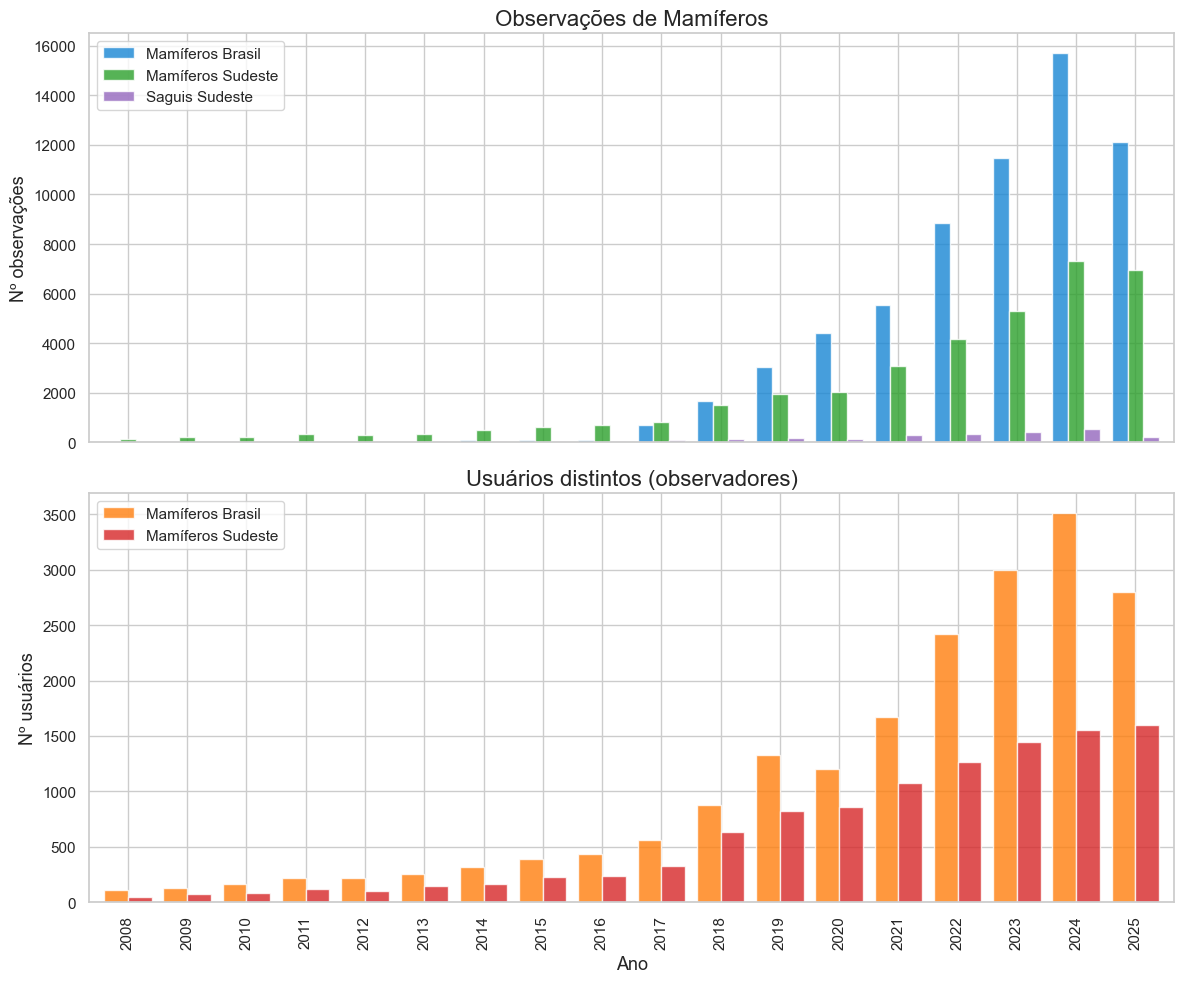

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# -----------------------------
# Painel 1: Observações
# -----------------------------
df_merged.set_index("year")[[
    'inat_obs_mammals_br',
    'inat_obs_mammals_sudeste',
    'inat_obs_mammals_sudeste_saguis'
]].plot(
    kind='bar', ax=ax1, width=0.8,
    color=["#1886d4", "#2ca02c", "#9467bd"], alpha=0.8
)
ax1.set_title("Observações de Mamíferos", fontsize=16)
ax1.set_ylabel("Nº observações", fontsize=13)
ax1.legend(["Mamíferos Brasil", "Mamíferos Sudeste", "Saguis Sudeste"], fontsize=11)

# -----------------------------
# Painel 2: Usuários
# -----------------------------
df_merged.set_index("year")[[
    'inat_users_mammals_br',
    'inat_users_mammals_sudeste'
]].plot(
    kind='bar', ax=ax2, width=0.8,
    color=["#ff7f0e", "#d62728"], alpha=0.8
)
ax2.set_title("Usuários distintos (observadores)", fontsize=16)
ax2.set_xlabel("Ano", fontsize=13)
ax2.set_ylabel("Nº usuários", fontsize=13)
ax2.legend(["Mamíferos Brasil", "Mamíferos Sudeste"], fontsize=11)

# Ajustes finais
plt.tight_layout()
plt.show()


In [11]:
# Save a Parquet file with the merged data
output_path = '../data/inaturalist/metrics/inat_gbif_mammals_sudeste_saguis_20250930.parquet'
df_merged.to_parquet(output_path, index=True)
print(f"Merged data saved to {output_path}")

Merged data saved to ../data/inaturalist/metrics/inat_gbif_mammals_sudeste_saguis_20250930.parquet
